# Lista 5

## Imports

In [446]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import Pipeline

 ## Zadanie 1



    pclass: Passenger class (1st, 2nd, or 3rd).
    survived: Survival status (0 = No, 1 = Yes).
    name: Passenger's name.
    sex: Passenger's gender.
    age: Passenger's age.
    sibsp: Number of siblings or spouses aboard.
    parch: Number of parents or children aboard.
    ticket: Ticket number.
    fare: Passenger fare.
    cabin: Cabin number.
    embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).
    boat: Lifeboat number (if survived).
    body: Body number (if not survived).
    home.dest: Home destination.


In [108]:
df = pd.read_csv('../4/Titanic Dataset.csv')

In [109]:
def extract_title(name):
    return name.split(',')[1].split('.')[0].strip()

In [110]:
df['cabin'] = df['cabin'].isna()
df['title'] = df['name'].apply(extract_title)
for title in df['title'].unique():
    mask = df['title'] == title
    df.loc[mask, 'age'] = df.loc[mask, 'age'].fillna(df.loc[mask, 'age'].median())

df['age'].fillna(df['age'].mean(), inplace=True)
df['fare'].fillna(df['fare'].mean(), inplace=True)
df['embarked'].fillna("S", inplace=True)

/tmp/ipykernel_5571/3509531941.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_5571/3509531941.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1309 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1309 non-null   float64
 9   cabin      1309 non-null   bool   
 10  embarked   1309 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
 14  title      1309 non-null   object 
dtypes: bool(1), float64(3), int64(4), object(7)
memory usage: 144.6+ KB


Usuwam kolumny boat, body, home.dest. Za duzo pustych wartosci

Usuwam name, bo juz mamy tytuly

In [112]:
df.drop(['body', 'home.dest', 'boat', 'name'], axis=1, inplace=True)

In [113]:
def convert_numeric(df, k, how, bin_edges=None):
    edges = bin_edges if bin_edges else {}
    new_df = df.copy()
    for col in df.columns:
        key = (how, col)

        if pd.api.types.is_numeric_dtype(df[col]):
            if how == 0:
                if key not in edges:
                    new_df[col], bins = pd.cut(df[col], k, retbins=True, include_lowest=True)
                    edges[key] = bins
                else:
                    new_df[col] = pd.cut(df[col], bins=edges[key], include_lowest=True)
            elif how == 1:
                if key not in edges:
                    new_df[col], bins = pd.qcut(df[col], k, duplicates='drop', retbins=True)
                    edges[key] = bins
                else:
                    new_df[col] = pd.cut(df[col], bins=edges[key], include_lowest=True)
            else:
                if key not in edges:
                    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
                    labels = kmeans.fit_predict(df[col].values.reshape(-1, 1))
                    edges[key] = kmeans
                else:
                    kmeans = edges[key]
                    labels = kmeans.predict(df[col].values.reshape(-1, 1))
                new_df[col] = labels
            new_df[col] = new_df[col].astype("category").cat.codes
    return new_df, edges

In [114]:
X = df.drop('survived', axis=1)
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        X[col] = X[col].astype("category").cat.codes
y = df['survived'].astype(bool)

In [115]:
X

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,title
0,1,0,29.00,0,0,187,211.3375,False,2,9
1,1,1,0.92,1,2,49,151.5500,False,2,8
2,1,0,2.00,1,2,49,151.5500,False,2,9
3,1,1,30.00,1,2,49,151.5500,False,2,12
4,1,0,25.00,1,2,49,151.5500,False,2,13
...,...,...,...,...,...,...,...,...,...,...
1304,3,0,14.50,1,0,259,14.4542,True,0,9
1305,3,0,22.00,1,0,259,14.4542,True,0,9
1306,3,1,26.50,0,0,250,7.2250,True,0,12
1307,3,1,27.00,0,0,264,7.2250,True,0,12


In [116]:
new_df, edges = convert_numeric(X, 5, 1)
new_df['age'] < 0

0       False
1       False
2       False
3       False
4       False
        ...  
1304    False
1305    False
1306    False
1307    False
1308    False
Name: age, Length: 1309, dtype: bool

In [127]:
ks = [2, 5, 10, 25]
hows = ["rowne", 'rownoliczne', 'kmeans']

res = {}

for i, how in enumerate(hows):
    results = []
    for k in ks:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
        X_train, edges = convert_numeric(X_train, k, i)
        X_test, _ = convert_numeric(X_test, k, i, bin_edges=edges)
        #catcodes return -1 sometimes
        X_train += 1
        X_test += 1

        model = CategoricalNB()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        score = accuracy_score(y_test, pred)
        results.append(round(score, 4))

    res[how] = results

/home/michal/PycharmProjects/Artificial-Inteligence/.venv/lib64/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/michal/PycharmProjects/Artificial-Inteligence/.venv/lib64/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/michal/PycharmProjects/Artificial-Inteligence/.venv/lib64/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/michal/PycharmProjects/Artificial-Inteligence/.venv/lib64/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of dist

In [128]:
pd.DataFrame(res, index=ks)

,rowne,rownoliczne,kmeans
2,0.8015,0.6794,0.8092
5,0.7863,0.7214,0.7824
10,0.7672,0.7443,0.7595
25,0.7863,0.7672,0.6603


## Zadanie 2

In [148]:
df = np.load('data5.npy')

In [149]:
df

array([[ -5.19811282,   0.64186932],
       [  0.77584883,   0.83500145],
       [-10.84489837,  -7.55352273],
       ...,
       [  4.24936943, -11.07055451],
       [  2.53417577,  -9.45082102],
       [  4.7740894 , -10.16165079]], shape=(1500, 2))

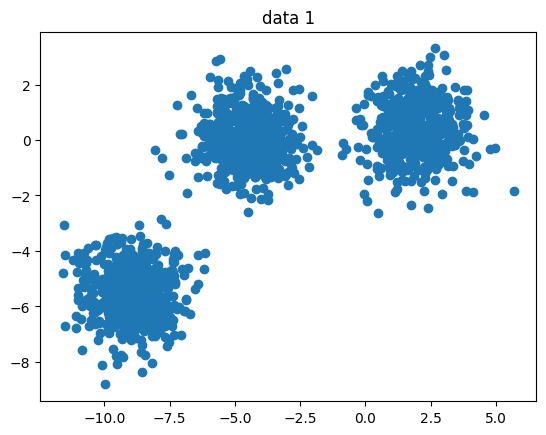

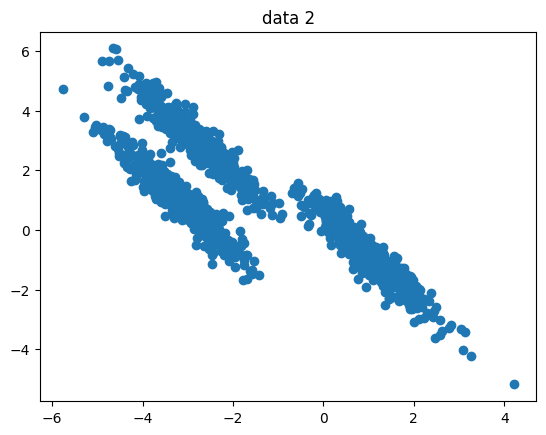

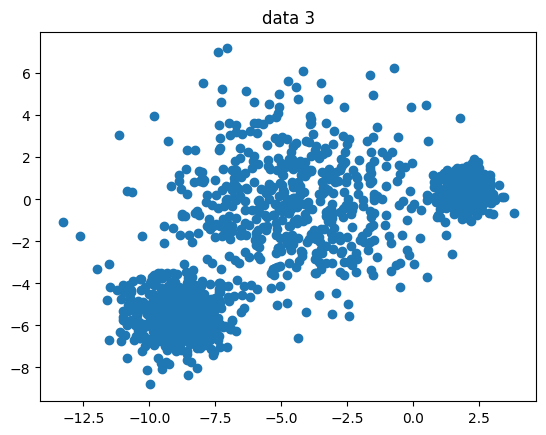

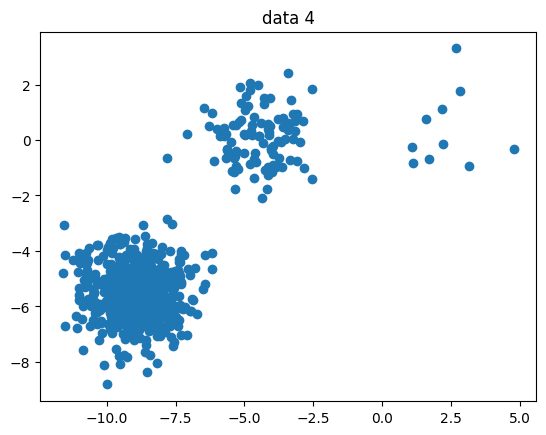

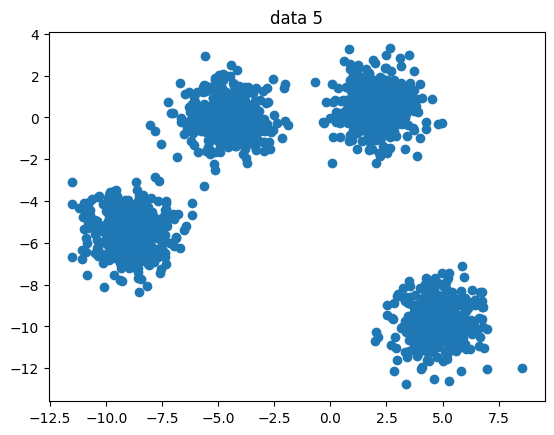

In [151]:
for i in range(1, 6):
    data = np.load(f'data{i}.npy')

    plt.scatter(data[:, 0], data[:, 1])
    plt.title(f'data {i}')
    plt.show()

Moje predykcje:
1. Kmeans
2. GMM
3. GMM
4. oba
5. ?

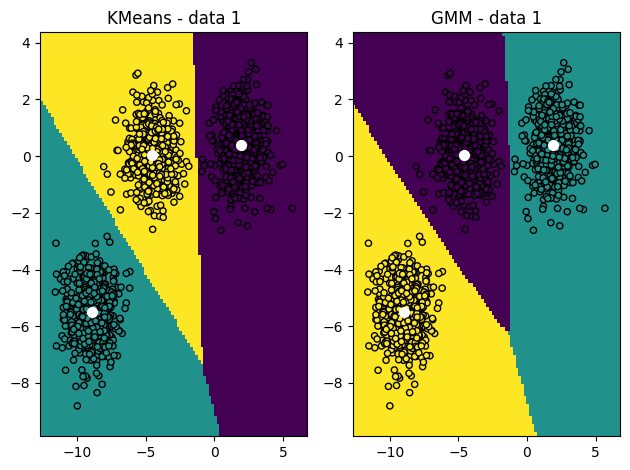

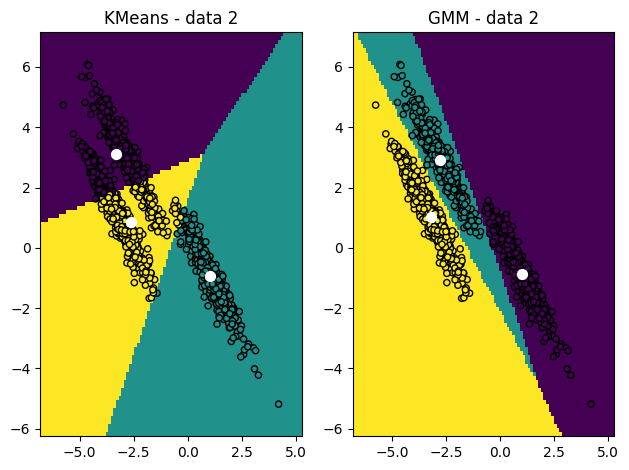

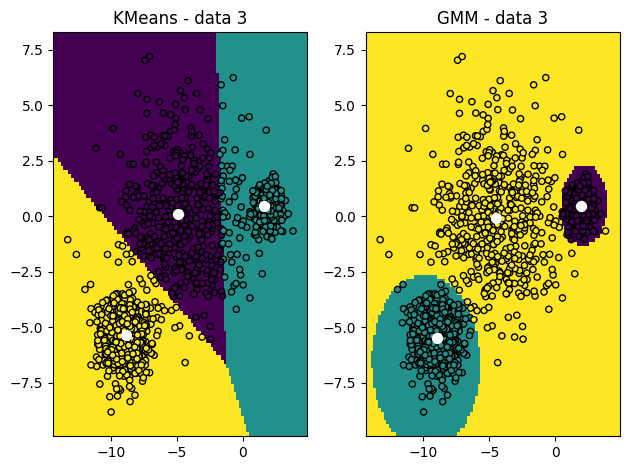

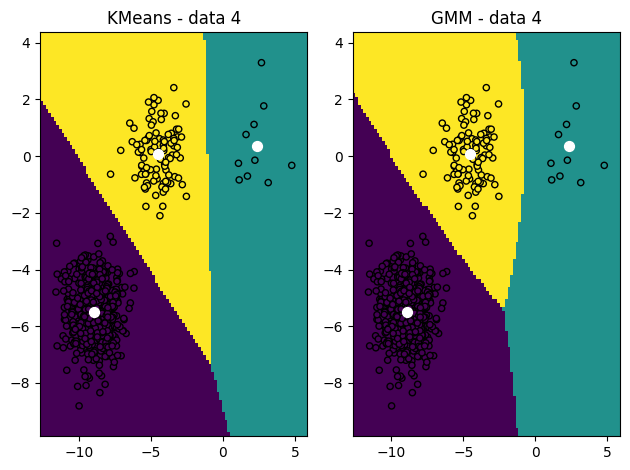

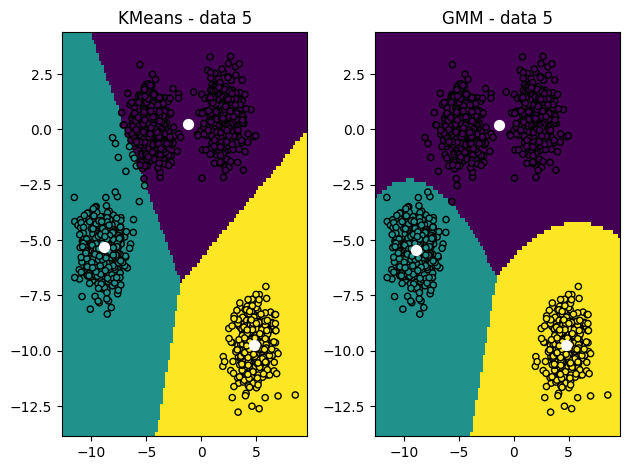

In [243]:
for i in range(1, 6):
    data = np.load(f'data{i}.npy')

    X = np.linspace(data[:, 0].min() - 1, data[:, 0].max() + 1,  100)
    Y = np.linspace(data[:, 1].min() - 1, data[:, 1].max() + 1,  100)
    Xv, Yv = np.meshgrid(X, Y)

    kmeans = KMeans(3, n_init=10, random_state=0).fit(data)
    labels_knn = kmeans.predict(np.vstack((Xv.ravel(), Yv.ravel())).T).reshape(Xv.shape)

    gmm = GaussianMixture(3, n_init=10, random_state=0).fit(data)
    labels_gmm = gmm.predict(np.vstack((Xv.ravel(), Yv.ravel())).T).reshape(Xv.shape)



    fig, ax = plt.subplots(1, 2)

    ax[0].pcolormesh(Xv, Yv, labels_knn)
    ax[0].scatter(data[:, 0], data[:, 1], c=kmeans.labels_, cmap="viridis", edgecolor="k", s=20)
    ax[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='.', s=200, c='white')
    ax[0].set_title(f'KMeans - data {i}')

    ax[1].pcolormesh(Xv, Yv, labels_gmm)
    ax[1].scatter(data[:, 0], data[:, 1], c=gmm.predict(data), cmap='viridis', edgecolor='k', s=20)
    ax[1].scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker='.', s=200, c='white')
    ax[1].set_title(f'GMM - data {i}')

    plt.tight_layout()
    plt.show()

Wyniki:
1. OBA
2. GMM
3. GMM
4. OBA
5. GMM

## Zadanie 3

In [320]:
emb = np.load('image_emb.npy')
labels = np.load('image_labels.npy', allow_pickle=True)

In [267]:
emb_df = pd.DataFrame(emb)
labels_df = pd.DataFrame(labels)

In [321]:
pd.DataFrame(labels).value_counts()

0         
              42450
airplane          5
automobile        5
bird              5
cat               5
deer              5
dog               5
frog              5
horse             5
ship              5
truck             5
Name: count, dtype: int64

In [322]:
idx = np.where(labels != '')

In [433]:
gmm = GaussianMixture(10, n_init=10, init_params='k-means++', random_state=0, reg_covar=1e-4).fit(emb[idx])

In [434]:
non_empty_labels = labels[idx]
non_empty_preds = gmm.predict(emb[idx])

counter = {}
for lab, pred in zip(non_empty_labels, non_empty_preds):
    if lab in counter:
        counter[lab].append(pred)
    else:
        counter[lab] = [pred]

convert = {}
for lab in counter.keys():
    res = [0] * 10
    for val in counter[lab]:
        res[val] += 1
    convert[np.argmax(res)] = lab

for i in range(10):
    if np.int64(i) not in convert:
        convert[np.int64(i)] = 'unknown'

In [435]:
convert

{np.int64(7): 'truck',
 np.int64(1): 'automobile',
 np.int64(6): 'dog',
 np.int64(0): 'deer',
 np.int64(5): 'airplane',
 np.int64(8): 'cat',
 np.int64(4): 'horse',
 np.int64(3): 'bird',
 np.int64(2): 'unknown',
 np.int64(9): 'unknown'}

In [436]:
labels_test = np.load('image_labels_test.npy')
emb_test = np.load('image_emb_test.npy', allow_pickle=True)

In [437]:
preds = gmm.predict(emb_test)
pred_labels = np.array([convert[c] for c in preds])

In [438]:
accuracy_score(labels_test, pred_labels)

0.47973333333333334

## Zadanie 4


In [444]:
newsgroups_train = fetch_20newsgroups()

In [443]:
# Create a pipeline with TfidfVectorizer and PCA
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('pca', KernelPCA(n_components=100, random_state=42))
])
# Fit and transform the data using the pipeline
pca_matrix = pipeline.fit_transform(newsgroups_train.data)
# Display the shape of the resulting matrix
print("Shape of PCA matrix:", pca_matrix.shape)

Shape of PCA matrix: (11314, 100)


In [445]:
pca_matrix

array([[ 0.00941207, -0.00258001, -0.00558156, ...,  0.02855973,
        -0.00208428,  0.03818625],
       [-0.09413626, -0.02887585,  0.01163306, ...,  0.08911024,
        -0.06102473, -0.01436269],
       [ 0.13944835, -0.0493732 ,  0.06480823, ..., -0.01227964,
         0.00121053,  0.02148313],
       ...,
       [-0.02265161, -0.07680551,  0.03126151, ...,  0.01024779,
         0.00134374, -0.01265826],
       [-0.04307311,  0.05155196,  0.01830913, ...,  0.08925317,
        -0.05453851, -0.04931056],
       [-0.1560807 ,  0.01190348, -0.0113248 , ...,  0.00069571,
         0.00331319, -0.00648237]], shape=(11314, 100))

In [450]:
inertias = []
silhouettes = []

for k in range(2, 20):
    kmeans = KMeans(k, n_init=10, random_state=0)
    kmeans.fit(pca_matrix)
    inertias.append(kmeans.inertia_)
    silhouette = silhouette_score(pca_matrix, kmeans.labels_)
    silhouettes.append(silhouette)
    print(f'K: {k}, Inertia: {kmeans.inertia_}, Silhouette: {silhouette}')

K: 2, Inertia: 1299.1682838698753, Silhouette: 0.11026254858640011
K: 3, Inertia: 1267.0371068468673, Silhouette: 0.054099798035579794
K: 4, Inertia: 1246.859769666045, Silhouette: 0.057111913121421394
K: 5, Inertia: 1235.4447296906521, Silhouette: 0.05617046482264999
K: 6, Inertia: 1223.433455600673, Silhouette: 0.044280946186581044
K: 7, Inertia: 1208.013904907518, Silhouette: 0.04803584805958834
K: 8, Inertia: 1190.8355695760413, Silhouette: 0.05365425351482066
K: 9, Inertia: 1177.221403560256, Silhouette: 0.057474983635881854
K: 10, Inertia: 1165.1905404014715, Silhouette: 0.05658246941403259
K: 11, Inertia: 1155.8846451295628, Silhouette: 0.05635123895081542
K: 12, Inertia: 1138.6728819390305, Silhouette: 0.05350902157495792
K: 13, Inertia: 1132.223570486342, Silhouette: 0.061118053000907294
K: 14, Inertia: 1120.0729396579845, Silhouette: 0.04808925074840113
K: 15, Inertia: 1113.1581484173303, Silhouette: 0.0494247647540975
K: 16, Inertia: 1095.3453642761092, Silhouette: 0.0613758